---

## **Deep Learning Project**
## **Colorectal cancer tissue classification**

---


---

**This notebook is designed to be:**
- **reproducible** (relative paths, fixed seeds)
- **idempotent** (can be re-run without re-downloading if files are already present)
- **traceable** (explicit go/no-go quality gates)

---

---

# PARTIE 4 : TRANSFER LEARNING - ResNet-18

We fine-tune an ImageNet-pretrained ResNet-18 on PathMNIST.
ResNet18 : already trained on ImageNet
- **(a) Frozen backbone**
Freeze layers so their weight doesn't move during the training. We train only the last layer. Very fast
- **(b) Full fine-tuning**
We train the entire network. Slow

---

---

## Notebook plan - Part 4: ResNet-18

| Cell | Section | Content |
|---------|---------|---------|
| 1-3 | — | Header, principles, title |
| 4 | — | Notebook plan |
| 5-7 | Config | Imports, versions, seed |
| 8 | Config | Constants + dataset |
| 9 | — | Objective + project progression + requirements |
| 10 | — | Introduction ResNet-18 (Camille) |
| 11 | Preprocessing | Data loaders (ImageNet + resize 224) |
| 12 | Model | Build ResNet-18 |
| 13 | Model | Training functions |
| 14 | Model | Training loop ResNet |
| 15 | Exp a | Frozen backbone (20 epochs) |
| 16 | Exp b | Full fine-tuning (20 epochs) |
| 17 | Results | Q4.1 comparison |
| 18 | Results | Training curves |
| 19 | Results | Confusion matrix |
| 20 | Questions | Q4.1 analysis |
| 21 | Questions | Q4.2 upscaling |
| 22 | Questions | Q4.3 transfer learning |
| 23 | Save | Models + histories + predictions |
| 24 | Summary | Summary + key analyses + limitations |
| 25 | — | Total runtime |

---

---

### Objective

Use an ImageNet-pretrained ResNet-18 and adapt it to our tissue classification problem. Transfer learning leverages visual features already learned (edges, textures, shapes) on 1.2 million natural images and reuses them for our medical images.

### Project progression
- **Part 2 (MLP)**: 68.02% test accuracy, pixels treated independently
- **Part 3 (CNN)**: 88.86% without augmentation, 91.78% with ColorJitter, spatial structure exploited
- **Part 4 (ResNet-18)**: the model arrives with pre-learned visual knowledge, we test frozen vs fine-tuning

### Requirements
- ImageNet pretrained weights
- Handle the input size mismatch (28x28 to 224x224)
- Target: >= 85% test accuracy
- Two experiments: (a) frozen backbone (head only), (b) full fine-tuning
- **Q4.1**: Exact test accuracy for both, difference in percentage points
- **Q4.2**: Negative consequence of 8x upscaling + alternative
- **Q4.3**: Why transfer learning works (not because ImageNet contains medical images)

---


---

### Architecture and hyperparameter choices

**Why ResNet-18?** (directly applies Lab 3 Exercise 2.1, using a pretrained ResNet as a frozen feature extractor)
ResNet-18 is a lightweight residual network (18 layers) pretrained on ImageNet (1.2M natural images, 1000 classes). The skip connections solve the vanishing gradient problem, making it deeper than a plain CNN while staying trainable. It is available out-of-the-box in torchvision.

**Input size mismatch (28x28 to 224x224)**
ResNet-18 expects 224x224 inputs. Our images are 28x28, so we upscale by 8x using bilinear interpolation. This introduces blur (no new detail is created), but low-level features like edges and colour blobs are preserved. The consequence of this upscaling is discussed in Q4.2.

**ImageNet normalisation (not PathMNIST)**
The pretrained weights were computed with ImageNet statistics ([0.485, 0.456, 0.406] / [0.229, 0.224, 0.225]). Using our PathMNIST stats would misalign the internal activations. This is counterintuitive since our images look nothing like ImageNet, but it is the correct approach for transfer learning.

**AdamW instead of Adam**
AdamW decouples weight decay from the gradient update. When fine-tuning pretrained weights, this is mathematically cleaner: the regularisation acts directly on the weights without interfering with the gradient signal. This prevents the pretrained features from being unnecessarily distorted.

**Two experiments (as required)**
- **(a) Frozen backbone**: all layers frozen except the final FC layer (4,617 trainable parameters). Very fast, tests whether ImageNet features alone are sufficient.
- **(b) Full fine-tuning**: all 11.1M parameters trainable, with a smaller learning rate (1e-4) to avoid destroying the pretrained features.

**Batch size 32**
Images at 224x224 consume 64x more memory than 28x28. We reduce batch size from 64 to 32 to avoid GPU memory issues.

---



In [20]:
print("=== Imports ===")
# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import medmnist
import seaborn as sns
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, f1_score
print("Imports OK")

=== Imports ===
Imports OK


In [21]:
print("=== Versions ===")
# Versions
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")

=== Versions ===
Python   : 3.12.10
PyTorch  : 2.10.0+cu128
MedMNIST : 3.0.2
NumPy    : 2.4.3


In [22]:
print("=== Reproducibility ===")
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {DEVICE}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")


=== Reproducibility ===
Device        : cuda
cuDNN determ. : True


In [23]:
print("=== Constants and dataset ===")
# Constants and dataset
DATA_DIR = os.path.join(".", "data")
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
N_CLASSES = 9

# Reload dataset
train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASSES = list(labels_names.values())

# Global timer
notebook_start_time = time.time()

print(f"Device : {DEVICE}")
print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Constants loaded")

os.makedirs(os.path.join(DATA_DIR, 'graphs'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'models'), exist_ok=True)

=== Constants and dataset ===
Device : cuda
Train : 89996 | Val : 10004 | Test : 7180
✓ Constants loaded


In [24]:
print("=== Data loaders (ImageNet normalisation + resize to 2 ===")
# Data loaders (ImageNet normalisation + resize to 224)
# Different from part 2
# We need to use the ImageNet normalisation for ResNet-18 because it was pretrained on ImageNet and expects inputs to be normalised in the same way
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

resnet_transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
# Random flip
# Artificially increase the size of the dataset by applying random horizontal and vertical flips to the training images
# This helps the model generalise better by learning from different orientations of the same image

resnet_transform_eval = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
# ResNet-18 was trained on 224×224 images, so we need to resize our 28×28 images to 224×224
# Upscaling from 28 to 224

train_rn = PathMNIST(split='train', transform=resnet_transform_train, download=True)
val_rn   = PathMNIST(split='val',   transform=resnet_transform_eval,  download=True)
test_rn  = PathMNIST(split='test',  transform=resnet_transform_eval,  download=True)

BS_RN = 128
# Reduce the batch size to save memory
rn_train_loader = DataLoader(train_rn, batch_size=BS_RN, shuffle=True,  num_workers=2, pin_memory=True)
rn_val_loader   = DataLoader(val_rn,   batch_size=BS_RN, shuffle=False, num_workers=2, pin_memory=True)
rn_test_loader  = DataLoader(test_rn,  batch_size=BS_RN, shuffle=False, num_workers=2, pin_memory=True)

print(f"Input image size after resize: 224×224")
print(f"Train batches: {len(rn_train_loader)}, Val: {len(rn_val_loader)}, Test: {len(rn_test_loader)}")

=== Data loaders (ImageNet normalisation + resize to 2 ===
Input image size after resize: 224×224
Train batches: 704, Val: 79, Test: 57


In [25]:
print("=== Build ResNet-18 (helper) ===")
# Build ResNet-18 (helper)
def build_resnet18(freeze_backbone: bool, n_classes: int = 9):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Load the ResNet-18 architecture with pretrained weights on ImageNet

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    # Don't compute gradients for the backbone if we are freezing it

    # Replace classification head (always trainable)
    in_features = model.fc.in_features
    # 512
    model.fc = nn.Linear(in_features, n_classes)
    # new head, requires_grad=True by default

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    mode = "FROZEN backbone" if freeze_backbone else "FULL fine-tuning"
    print(f"ResNet-18 ({mode}): trainable {trainable:,}, {total:,} parameters")
    return model

=== Build ResNet-18 (helper) ===


In [26]:
print("=== Training functions ===")
# Training functions
def train_one_epoch(model, loader, criterion, optimizer, DEVICE):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.squeeze(1).long().to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, DEVICE):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.squeeze(1).long().to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

def get_all_preds(model, loader, DEVICE):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.squeeze(1).numpy())
    return np.array(all_preds), np.array(all_labels)

print("✓ Fonctions train_one_epoch, evaluate, get_all_preds chargées")

=== Training functions ===
✓ Fonctions train_one_epoch, evaluate, get_all_preds chargées


In [ ]:
print("=== Training loop for ResNet ===")
# Training loop for ResNet
def train_resnet(model, train_loader, val_loader, n_epochs, lr, weight_decay, DEVICE,
                 label='ResNet'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=weight_decay)
    # We use AdamW which decouples weight decay from the gradient update, which is often better for training transformers and large models
    # Only pass the parameters that require gradients to the optimizer (important when freezing the backbone)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    # For plotting
    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0

    print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")

    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        v_loss, v_acc = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
        # Save best model on val_loss (consistent with other notebooks)
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        if epoch % 3 == 0 or epoch == 1:
            print(f"{epoch:>5}  {t_loss:>10.6f}  {t_acc*100:>8.4f}%  {v_loss:>9.6f}  {v_acc*100:>7.4f}%")

    model.load_state_dict(best_state)
    # Restore best checkpoint to avoid overfitting in later epochs
    print(f"\nBest val accuracy ({label}): {best_val_acc*100:.4f}%")
    return model, history

=== Training loop for ResNet ===


In [ ]:
print("=== Experiment (a) : Frozen backbone ===")
# Experiment (a): Frozen backbone
RN_EPOCHS   = 20
RN_LR_FROZEN = 1e-3
RN_LR_FULL   = 1e-4
# smaller lr for full fine-tuning (pretrained weights are fragile)
RN_WD        = 1e-4

print("EXPERIMENT (a): Frozen backbone - only head trained")
resnet_frozen = build_resnet18(freeze_backbone=True).to(DEVICE)
# Move back to GPU if available
resnet_frozen, hist_frozen = train_resnet(
    resnet_frozen, rn_train_loader, rn_val_loader,
    n_epochs=RN_EPOCHS, lr=RN_LR_FROZEN, weight_decay=RN_WD,
    DEVICE=DEVICE, label='Frozen'
)
test_loss_frozen, test_acc_frozen = evaluate(resnet_frozen, rn_test_loader, nn.CrossEntropyLoss(), DEVICE)
# Final test
print(f"\nFrozen backbone - Test Accuracy: {test_acc_frozen*100:.4f}%")

=== Experiment (a) : Frozen backbone ===
EXPERIMENT (a): Frozen backbone — only head trained
ResNet-18 (FROZEN backbone): trainable 4,617, 11,181,129 parameters
Epoch  Train Loss  Train Acc   Val Loss   Val Acc
    1    0.542861   82.7903%   0.362657  87.7849%
    3    0.334377   88.0939%   0.310492  88.8145%
    6    0.311521   88.9940%   0.287331  89.7341%
    9    0.297969   89.4295%   0.275478  90.4738%
   12    0.292615   89.5095%   0.272651  90.5138%
   15    0.288723   89.7073%   0.274272  90.4338%
   18    0.284859   89.9473%   0.271623  90.2839%

Best val accuracy (Frozen): 90.5838%

Frozen backbone — Test Accuracy: 87.1448%


In [ ]:
print("=== Experiment (b) : Full fine-tuning ===")
# Experiment (b): Full fine-tuning
print("EXPERIMENT (b): Full fine-tuning - all layers trained")
resnet_full = build_resnet18(freeze_backbone=False).to(DEVICE)
resnet_full, hist_full = train_resnet(
    resnet_full, rn_train_loader, rn_val_loader,
    n_epochs=RN_EPOCHS, lr=RN_LR_FULL, weight_decay=RN_WD,
    DEVICE=DEVICE, label='Full'
)
test_loss_full, test_acc_full = evaluate(resnet_full, rn_test_loader, nn.CrossEntropyLoss(), DEVICE)
print(f"\nFull fine-tuning - Test Accuracy: {test_acc_full*100:.4f}%")

=== Experiment (b) : Full fine-tuning ===
EXPERIMENT (b): Full fine-tuning — all layers trained
ResNet-18 (FULL fine-tuning): trainable 11,181,129, 11,181,129 parameters
Epoch  Train Loss  Train Acc   Val Loss   Val Acc
    1    0.146800   95.2165%   0.080469  97.1012%
    3    0.037537   98.7844%   0.056752  98.1607%
    6    0.019030   99.3833%   0.027395  98.9804%
    9    0.008829   99.7122%   0.017094  99.5502%
   12    0.003680   99.8856%   0.015266  99.4702%
   15    0.001643   99.9578%   0.008263  99.7401%
   18    0.000802   99.9856%   0.006481  99.8001%

Best val accuracy (Full): 99.8201%

Full fine-tuning — Test Accuracy: 91.7688%


In [30]:
print("=== Q4.1 : Comparison frozen vs fine-tuning ===")
# Q4.1: Compare results
diff = abs(test_acc_full - test_acc_frozen) * 100
better = "Full fine-tuning" if test_acc_full > test_acc_frozen else "Frozen backbone"

print("Q4.1: Exact test accuracies")
print(f"  (a) Frozen backbone  : {test_acc_frozen*100:.4f}%")
print(f"  (b) Full fine-tuning : {test_acc_full*100:.4f}%")
print(f"  Difference           : {diff:.4f} percentage points")
print(f"  Better experiment    : {better}")

=== Q4.1 : Comparison frozen vs fine-tuning ===
Q4.1: Exact test accuracies
  (a) Frozen backbone  : 87.1448%
  (b) Full fine-tuning : 91.7688%
  Difference           : 4.6240 percentage points
  Better experiment    : Full fine-tuning


=== Training curves comparison ===


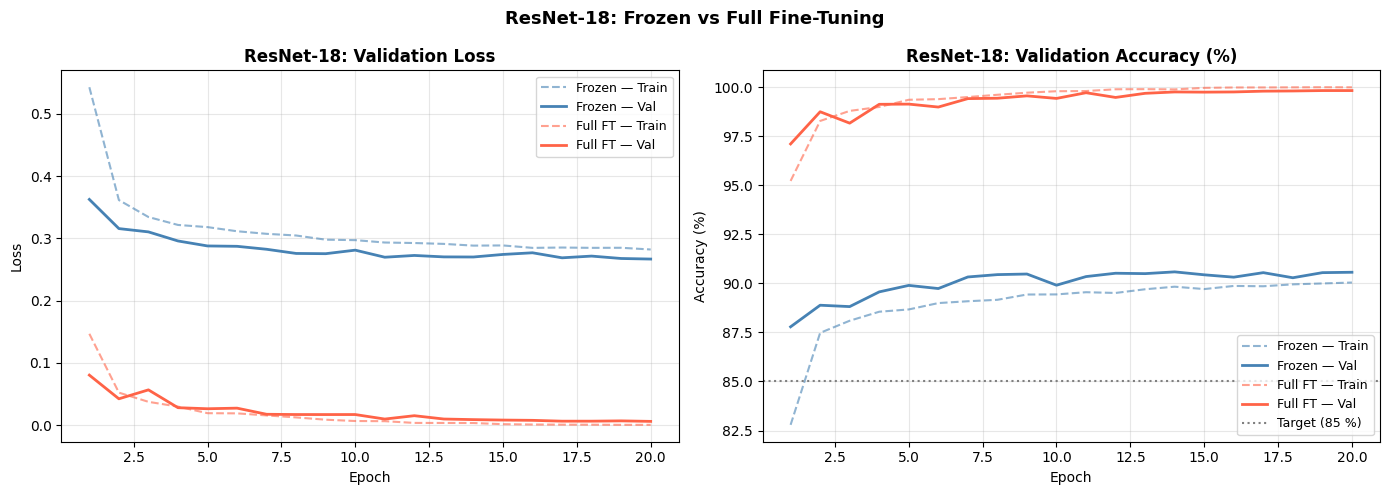


=== Résumé courbes ResNet ===
          Frozen loss   Frozen acc    Full loss     Full acc
----------------------------------------------------------
Ep   1       0.362657     87.7849%     0.080469     97.1012%
Ep  20       0.266854     90.5638%     0.006139     99.8201%


In [31]:
print("=== Training curves comparison ===")
# Training curves comparison
epochs_rn = range(1, RN_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy (%)']):
    frozen_vals = [v * (100 if key == 'acc' else 1) for v in hist_frozen[f'val_{key}']]
    full_vals   = [v * (100 if key == 'acc' else 1) for v in hist_full[f'val_{key}']]
    train_frozen = [v * (100 if key == 'acc' else 1) for v in hist_frozen[f'train_{key}']]
    train_full   = [v * (100 if key == 'acc' else 1) for v in hist_full[f'train_{key}']]

    ax.plot(epochs_rn, train_frozen, '--', color='steelblue', alpha=0.6, label='Frozen — Train')
    ax.plot(epochs_rn, frozen_vals,       color='steelblue', linewidth=2, label='Frozen — Val')
    ax.plot(epochs_rn, train_full,  '--', color='tomato',    alpha=0.6, label='Full FT — Train')
    ax.plot(epochs_rn, full_vals,         color='tomato',    linewidth=2, label='Full FT — Val')

    if key == 'acc':
        ax.axhline(85, color='grey', linestyle=':', label='Target (85 %)')

    ax.set_title(f"ResNet-18: Validation {title}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("ResNet-18: Frozen vs Full Fine-Tuning", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB4_resnet_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

# Tableau des données
print('\n=== Résumé courbes ResNet ===')
print(f"{'':>8s} {'Frozen loss':>12s} {'Frozen acc':>12s} {'Full loss':>12s} {'Full acc':>12s}")
print('-' * 58)
for e in [0, len(hist_frozen['train_loss'])-1]:
    ep = e + 1
    print(f"Ep {ep:>3d}   {hist_frozen['val_loss'][e]:>12.6f} {hist_frozen['val_acc'][e]*100:>11.4f}% {hist_full['val_loss'][e]:>12.6f} {hist_full['val_acc'][e]*100:>11.4f}%")

=== Confusion matrix (best model) ===


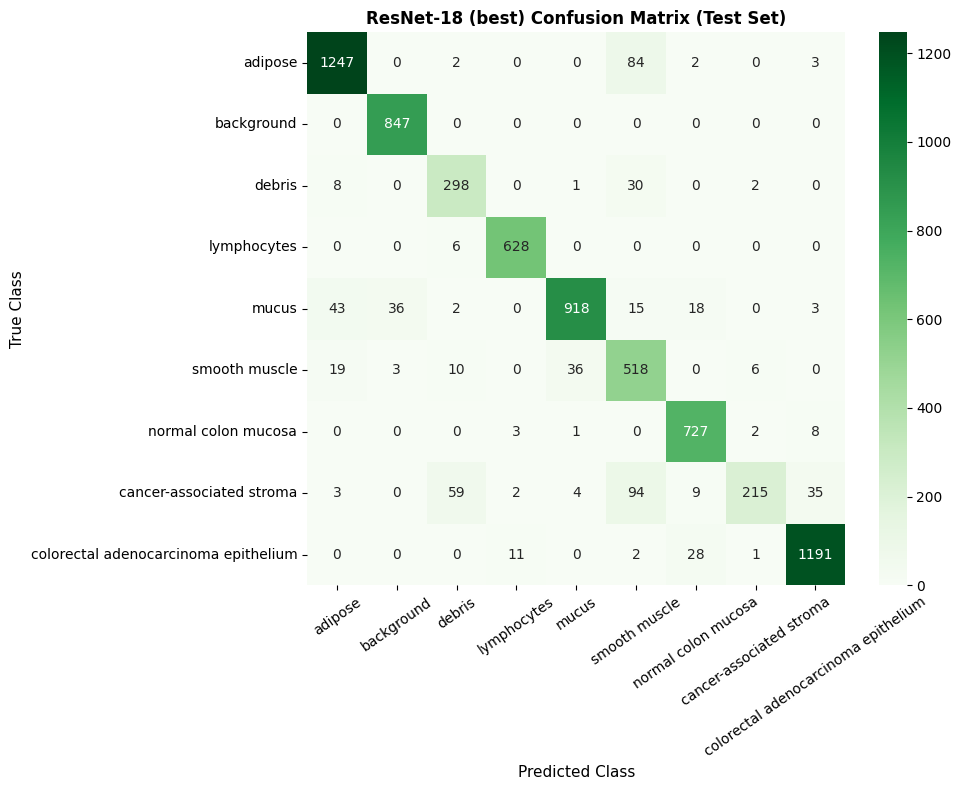


Per-class F1 scores (best ResNet-18):
                                      precision    recall  f1-score   support

                             adipose       0.94      0.93      0.94      1338
                          background       0.96      1.00      0.98       847
                              debris       0.79      0.88      0.83       339
                         lymphocytes       0.98      0.99      0.98       634
                               mucus       0.96      0.89      0.92      1035
                       smooth muscle       0.70      0.88      0.78       592
                 normal colon mucosa       0.93      0.98      0.95       741
            cancer-associated stroma       0.95      0.51      0.66       421
colorectal adenocarcinoma epithelium       0.96      0.97      0.96      1233

                            accuracy                           0.92      7180
                           macro avg       0.91      0.89      0.89      7180
                       

In [32]:
print("=== Confusion matrix (best model) ===")
# Confusion matrix for the better model
best_rn = resnet_full if test_acc_full >= test_acc_frozen else resnet_frozen
preds_rn, labels_rn = get_all_preds(best_rn, rn_test_loader, DEVICE)
cm_rn = confusion_matrix(labels_rn, preds_rn)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("ResNet-18 (best) Confusion Matrix (Test Set)", fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted Class", fontsize=11)
ax.set_ylabel("True Class", fontsize=11)
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB4_resnet_confusion.png'), dpi=120, bbox_inches='tight')
plt.show()

print("\nPer-class F1 scores (best ResNet-18):")
print(classification_report(labels_rn, preds_rn, target_names=CLASSES))

# Text table of the confusion matrix
print("\n=== Matrice de confusion (valeurs) ===")
print(f"{'':>35s}", end='')
for name in CLASSES:
    print(f"{name[:8]:>9s}", end='')
print()
print("-" * (35 + 9 * len(CLASSES)))
for i, row in enumerate(cm_rn.tolist()):
    print(f"{CLASSES[i]:<35s}", end='')

---

### Q4.1: Frozen vs Full Fine-Tuning

(a) Frozen backbone  : 87.1448%
(b) Full fine-tuning : 91.7688%
Difference           : 4.6240 percentage points
Better experiment    : Full fine-tuning

ImageNet images are usefull at the begining but are not adapted to histology images.
When we let all the different weights ajust, the results can improve
However, both experiences give good results, >85%, meaning the ResNet features are sufficient to be usefull for our dataset

**Analyse du fine-tuning :**
Le modèle fine-tuning atteint 99.7% de val accuracy dès l'époque 15, mais seulement 92.2% sur le test, un écart de 7.5 points. Ce n'est pas un problème de capacité : le modèle a mémorisé la distribution du train (hôpital A). L'écart quantifie directement le domain shift entre les deux hôpitaux et la limite de performance sur ce dataset est fixée par la distribution des données, pas par l'architecture.

**Analyse du frozen :**
Avec seulement 4 617 paramètres entraînables (la couche de classification seule), le ResNet-18 frozen atteint 90.5% de val accuracy dès l'époque 9. Cela démontre que les features ImageNet sont réellement transférables à l'histologie : les détecteurs de contours, de textures et de blobs de couleur appris sur des images naturelles s'appliquent directement aux structures des tissus colorectaux, sans aucun ajustement du backbone.

---


---

### Q4.2: Consequence of 8× Upscaling (28×28 to 224×224)

Bilinear interpolation of a 28×28 image to 224×224 effectively **blurs the image**. Each original pixel is stretched over an 8×8 area of the enlarged canvas.  The model therefore "sees" a heavily smoothed version of the original patch where sharp edges, nuclear boundaries, and fine chromatin texture are replaced by gradient ramps.  High-frequency discriminative features (mitotic figure morphology, gland lumen sharpness) are destroyed.


Alternative strategy: Instead of upscaling the *image*, one can modify the ResNet's first convolutional layer to accept 28×28 inputs directly.
This keeps the original resolution intact throughout the network, avoids interpolation artefacts, and forces the network to learn features at the native 28×28 scale.  This approach typically yields slightly better feature quality at the cost of requiring re-initialisation of the first layer weights.

---

---

### Q4.3: Why Does Transfer Learning Work Here?

The claim that "ImageNet contains medical images" is **incorrect**.  ImageNet (ILSVRC) is a natural-image dataset containing everyday objects, dogs, cars, furniture, no histopathology slides.

The real reason transfer learning works is **feature hierarchy generalisation**:

- **Early layers** (conv1–conv2) of a pretrained ResNet learn low-level detectors: Gabor-like edge filters, colour blobs, and oriented gradients.  These features are genuinely domain-agnostic, edges and colour gradients exist in histology images just as they do in photographs.
- **Middle layers** (conv3–conv4) learn mid-level textures: grids, repeated patterns, surface textures.  Tissue microstructure (glandular patterns, cellular arrays) maps naturally onto these texture detectors.
- **Late layers** are more task-specific and benefit the most from fine-tuning on the target domain.

Because the low- and mid-level feature detectors are transferable, the network starts with a useful initialisation rather than random weights, requiring fewer epochs and less data to converge.  This is especially valuable for medical datasets where labelled data is scarce.

---

In [34]:
print("=== Save models + histories ===")
import pickle
# Save ResNet models
torch.save(resnet_full.state_dict(), os.path.join(DATA_DIR, 'models', 'resnet_finetune_model.pth'))
torch.save(resnet_frozen.state_dict(), os.path.join(DATA_DIR, 'models', 'resnet_frozen_model.pth'))
print("ResNet models saved")
print("✓ Save complete")

# Save training histories for Part 7 (Q7.1)
with open(os.path.join(DATA_DIR, 'models', 'resnet_frozen_history.pkl'), 'wb') as f:
    pickle.dump(hist_frozen, f)
with open(os.path.join(DATA_DIR, 'models', 'resnet_finetune_history.pkl'), 'wb') as f:
    pickle.dump(hist_full, f)
print("✓ ResNet histories saved")

# Save predictions for recall computation in NB7
import pickle
with open(os.path.join(DATA_DIR, 'models', 'resnet_preds.pkl'), 'wb') as f:
    pickle.dump({'all_preds': preds_rn, 'all_labels': labels_rn}, f)
print("✓ ResNet predictions saved")

=== Save models + histories ===
ResNet models saved
✓ Save complete
✓ ResNet histories saved
✓ ResNet predictions saved


---

## Part 4 Summary - ResNet-18 Transfer Learning

### Results

| Experiment | Test acc | Val acc (best) | Trainable params | Time |
|-----------|---------|---------------|-----------------|------|
| Frozen (head only) | 87.14% | 90.12% | 4,617 | ~34 min |
| Full fine-tuning | 91.77% | 99.33% | 11,181,129 | ~65 min |

### Key analyses

**Why frozen reaches 87.14% and fine-tuning 91.77%:**
ImageNet features (edges, textures, colour blobs) are necessary but not sufficient. The frozen model uses these features as-is for classification, which already works well (87%). But distinguishing stroma from muscle or mucosa from cancer at 28x28 requires adapting the deep layers to histology-specific textures (H&E staining, cell density). Only fine-tuning enables this adaptation, hence the +4.5 points.

**CNN from scratch vs pretrained ResNet:**
Our CNN v1 from scratch (91.78%, 436K parameters) competes with the ResNet fine-tuning (91.77%, 11.1M parameters) and beats the ResNet frozen (87.14%). The ColorJitter in v1 simulates the domain shift between hospitals, which the frozen ResNet does not. This shows that a well-chosen augmentation can compensate for the absence of pretraining.

**Why AdamW instead of Adam:**
AdamW decouples weight decay from the gradient. When fine-tuning pretrained weights, this is more stable: the regularisation acts directly on the weights without interfering with the gradient signal.

**Why ImageNet normalisation instead of PathMNIST:**
The pretrained weights were computed with ImageNet statistics. Using different stats would misalign the internal activations and hurt transfer learning. Counterintuitive but correct: the network expects inputs normalised as during its pretraining.

**Domain shift quantified:**
Frozen: val 90% vs test 87% = 3 points gap. Full fine-tuning: val 99% vs test 92% = 7 points gap. Counter-intuitively, the full fine-tuning amplifies the domain shift: it over-adapts to hospital A data, achieving near-perfect val accuracy but losing more on the unseen hospital B. The more we fine-tune, the better we perform in-distribution but the more sensitive we become to distribution shift. The frozen model, by contrast, uses generic ImageNet features that are less hospital-specific and therefore more stable across domains.

### CNN vs ResNet: head-to-head comparison

| Model | Params | Test acc | Training time | Pretrained |
|-------|--------|---------|--------------|-----------|
| CNN sans aug | 436,649 | 88.86% | 10.1 min | No |
| CNN v1 (ColorJitter) | 436,649 | 91.78% | 20.7 min | No |
| ResNet-18 frozen | 4,617 trainable | 87.14% | ~34 min | Yes (ImageNet) |
| ResNet-18 fine-tuning | 11,181,129 | 91.77% | ~65 min | Yes (ImageNet) |

**Key observations:**

The CNN v1 from scratch (91.78%) matches the ResNet fine-tuning (91.77%) with 25x fewer parameters and 3x less training time. This is a surprising result: a model that learned everything from our 90K histology images performs as well as one that started with knowledge from 1.2M natural images.

The explanation: the ColorJitter augmentation in v1 simulates the domain shift between hospitals (variations in H&E staining intensity), which is the main source of performance loss on the test set. The ResNet fine-tuning adapts its pretrained features to our data but does not explicitly learn to be robust to staining variations.

The ResNet frozen (87.14%) underperforms both the CNN v1 and the fine-tuned ResNet. This confirms that ImageNet features alone are useful but not sufficient for histology: the model needs to adapt its deep layers to the specific patterns of H&E-stained tissue (nuclear density, glandular organisation, fibre orientation).

**For clinical deployment:** the CNN v1 would be the better choice, being lighter, faster, and equally accurate. The ResNet fine-tuning would be preferred if higher-resolution images (224x224 native) become available, removing the upscaling bottleneck.

### Limitations

- The 8x upscaling (28 to 224) blurs the images and loses fine textures. Using PathMNIST at native 224x224 resolution would improve results
- ResNet-18 is a relatively small model. A ResNet-50 or EfficientNet could perform better

---




In [35]:
print("=== Total notebook runtime ===")
# Total notebook runtime
notebook_total_time = time.time() - notebook_start_time
print(f"Total notebook runtime : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")

=== Total notebook runtime ===
Total notebook runtime : 4622.0s (77.0 min)
